# Build the countries shapefile

Generate a shapefile with all the countries.


### Input data:

**Natural Earth**: Admin 0, Countries — [Natural Earth 1:10m Cultural Vectors](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/)

### Input data license:

CC0 1.0 Universal (public domain)

Giulia Cigna - giulia.cigna@polito.it<br>
Romain Thomas - romain.thomas@polito.it<br>
2026

In [1]:
import os
from dotenv import load_dotenv
import geopandas as gpd
import logging
import pandas as pd
from shapely.geometry import box
from shapely.geometry import MultiPolygon
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import pycountry
import chardet
from pathlib import Path

## LOGGING

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    datefmt='%Y-%m-%d %H:%M:%S',
    force=True
)

## SETTINGS

In [3]:
if not os.path.exists(".env"):
    raise ValueError("You must create the '.env' file and set the values before running this notebook.")

load_dotenv()

True

## OUTPUT SETTINGS

In [4]:
# Get full shapefile path from environment
countries_from_ne_path = os.getenv("COUNTRIES_FROM_NE_PATH")
if countries_from_ne_path is None:
    raise ValueError("COUNTRIES_FROM_NE_PATH environment variable is not set")

# Create directory if it doesn't exist
Path(countries_from_ne_path).parent.mkdir(parents=True, exist_ok=True)

logging.info(f"Output path: {countries_from_ne_path}")

2026-03-13 18:01:55 - root - INFO - Output path: data/countries_from_ne_10m/countries_from_ne_10m.shp


## INPUT FILES

In [5]:
ne_admin_countries_path = os.getenv("NE_ADMIN_COUNTRIES_PATH")
if ne_admin_countries_path is None:
    raise ValueError("NE_ADMIN_COUNTRIES_PATH environment variable is not set")
countries_from_ne_path = os.getenv("COUNTRIES_FROM_NE_PATH")
if countries_from_ne_path is None:
    raise ValueError("COUNTRIES_FROM_NE_PATH environment variable is not set")

codes_id_path = os.getenv('CODES_ID_PATH')
if codes_id_path is None:
    raise ValueError("CODES_ID_PATH environment variable is not set")

## READING INPUT FILES

In [6]:
logging.info(f"Reading shapefile for NATURAL EARTH from {ne_admin_countries_path}")
gdf_countries = gpd.read_file(ne_admin_countries_path)

2026-03-13 18:01:55 - root - INFO - Reading shapefile for NATURAL EARTH from data/ne_10m/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp


In [7]:
logging.info(f"Reading ids from {codes_id_path}")
with open(codes_id_path, "rb") as f:
    result = chardet.detect(f.read())

# from https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html#na-values
na_vals = ['-1.#IND', '1.#QNAN', '1.#IND', '-1.#QNAN', '#N/A N/A', '#N/A', 'N/A', 'n/a', 'NA', '<NA>', '#NA', 'NULL', 'null', 'NaN', '-NaN', 'nan', '-nan', 'None', '']
# avoids errors with country code "NA":
na_vals.remove('NA')

codes_id = pd.read_csv(
    codes_id_path,
    encoding=result["encoding"],
    sep=None,
    engine="python",
    keep_default_na=False,
    na_values=na_vals
)


2026-03-13 18:01:55 - root - INFO - Reading ids from data/codes_id.csv


## FILTER COLUMS OF INPUT FILES

In [8]:
# Scheme definition of the final shape file

schema = {
    "ID": "str:10",
    "NAME": "str:50",
    "ISO3_CODE": "str:3",
    "ISO2_CODE": "str:2",
    "ISON_CODE": "int",
    "NUM_ID": "int",
    "NE_ID": "int",
#    "OL_NAME": "str:50",
    "SOURCE": "str:50",
    "geometry": "MultiPolygon"
}


Mapping between original shape file columns and finale scheme

In [9]:
# Countries
attr_countries = [c for c in gdf_countries.columns if c != "geometry"]

logging.info(f"Attributes in the Countries shape file are: {attr_countries}")

2026-03-13 18:01:55 - root - INFO - Attributes in the Countries shape file are: ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A

In [10]:
# Mapping scheme specific of Natural Earth data
countries_columns_map = {
    'NAME_LONG': "NAME",
    'ISO_A3': "ISO3_CODE",
    'ISO_A2': "ISO2_CODE",
    'ISO_N3': "ISON_CODE",
    'NE_ID': "NE_ID"
}


In [11]:
# Mapping function

def prepare_gdf(gdf, col_map, fixed_values=None):
    gdf = gdf.copy()

    # Keep only columns that are in the mapping (+ geometry)
    cols_to_keep = list(col_map.keys()) + ["geometry"]
    gdf = gdf[[col for col in cols_to_keep if col in gdf.columns]]

    # Rename columns
    gdf = gdf.rename(columns=col_map)

    # Create missing columns with placeholders
    for col in schema:
        if col not in gdf.columns and col != "geometry":
            gdf[col] = None

    # Apply fixed values
    if fixed_values:
        for col, val in fixed_values.items():
            gdf[col] = val

    # Keep only target columns (ORDERED by schema)
    gdf = gdf[list(schema)]

    return gdf


In [12]:
# Mapping the input gdf

gdf_countries = prepare_gdf(
    gdf_countries,
    countries_columns_map
)

logging.info(f"Attributes in the modified Countries shape file are: {gdf_countries.columns}")


2026-03-13 18:01:55 - root - INFO - Attributes in the modified Countries shape file are: Index(['ID', 'NAME', 'ISO3_CODE', 'ISO2_CODE', 'ISON_CODE', 'NUM_ID', 'NE_ID',
       'SOURCE', 'geometry'],
      dtype='str')


In [13]:
# Adding IDs to identify all the regions (even if they don't have ISO codes)

# Build lookup from codes_id.csv
lookup = codes_id.dropna(subset=["NE_ID"]).set_index("NE_ID")["ID"]

# Add and fill the new column
gdf_countries["ID"] = gdf_countries["NE_ID"].map(lookup)

In [14]:
# Change -99 values into NAN
gdf_countries['ISO3_CODE'] = gdf_countries['ISO3_CODE'].replace({'-99': None, -99: None})
gdf_countries['ISO2_CODE'] = gdf_countries['ISO2_CODE'].replace({'-99': None, -99: None})
gdf_countries['ISON_CODE'] = gdf_countries['ISON_CODE'].replace({'-99': None, -99: None})

## SPLIT EXTRA-TERRITORIES

Some regions contain inside more than one country. Here a function to split them.

In [15]:
# Duplicate the original gdf
gdf_countries_new = gdf_countries

# Function to split countries
def split_countries(gdf_cntr_original, gdf_cntr_final, cntr_name, split_box, row_attributes):
    """
    Split countries and adds a new row.

    Parameters:
        gdf_cntr_original: input original gdf with countries
        gdf_cntr_final: final gdf with countries
        cntr_name: string with big country name
        split_box: box or list of boxes that contains the areas to split
        row_attributes: list of known attributes of the country to split

    Returns:
        Updated GeoDataFrame
    """

    # Check if the target country is there or if was already processed
    if gdf_cntr_original[gdf_cntr_original["NAME"] == cntr_name].empty:
        logging.info(f"Country {cntr_name} not found, skipping")
        return None
    # elif not gdf_cntr_final[gdf_cntr_final[id] == row_attributes["ID"]].empty:
    #     logging.info(f"Country {row_attributes['ID']} already split, skipping")
    #     return None
    else:
        logging.info(f"Country {cntr_name} processing...")


        cntr = gdf_cntr_original[gdf_cntr_original["NAME"] == cntr_name]

        # Get the original country geometry
        cntr_geom = cntr.geometry.iloc[0]

        # Explode MultiPolygon into individual polygons if needed
        polygons = list(cntr_geom.geoms) if isinstance(cntr_geom, MultiPolygon) else [cntr_geom]
        polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs=gdf_cntr_original.crs)

        # Deal with both single box or list of boxes
        if not isinstance(split_box, (list, tuple)):
            split_box = [split_box]

        # Select polygons intersecting any SPLIT COUNTRY box
        split_country_parts = polygons_gdf[
            polygons_gdf.geometry.apply(
                lambda g: any(g.intersects(b) for b in split_box)
            )
        ]

        # Merge all split parts into a single geometry
        split_country = split_country_parts.union_all()

        if split_country.is_empty:
            logging.warning(f"No geometry found for {row_attributes["NAME"]}")
            return gdf_cntr_final

        if cntr_name == row_attributes["NAME"]:
            logging.info(f"Mainland processing...")

            # Changing the geometry of the big country
            gdf_cntr_final.loc[gdf_cntr_final["NAME"] == cntr_name, "geometry"] = split_country

        else:
            logging.info(f"Splitting {row_attributes["NAME"]} from {cntr_name} ...")

            # Add the new geometry to the attributes
            row_attributes["geometry"] = split_country

            # New row definition
            new_row = gpd.GeoDataFrame(
                [row_attributes],
                geometry="geometry",
                crs=gdf_countries_new.crs
            )

            # Adding the new row to the new gdf
            gdf_cntr_final = pd.concat(
                [gdf_cntr_final, new_row],
                ignore_index=True
            )

            if gdf_cntr_final[gdf_cntr_final["NAME"] == row_attributes["NAME"]].empty:
                logging.info(f"Country {row_attributes["NAME"]} not found, splitting not done")
            else:
                logging.info(f"Country {row_attributes["NAME"]} split successfully and added to the final gdf")

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

        # --- Original Geometry ---
        gpd.GeoSeries([cntr_geom]).plot(
            ax=axes[0],           # plot on first subplot
            color='lightblue',
            edgecolor='black',
            linewidth=1.5
        )
        axes[0].set_title(f"{cntr_name} Original Geometry", fontsize=14)
        axes[0].set_xlabel("Longitude")
        axes[0].set_ylabel("Latitude")
        axes[0].set_xlim(-180,180)
        axes[0].set_ylim(-90,90)

        # --- Split Geometry ---
        gpd.GeoSeries([split_country]).plot(
            ax=axes[1],           # plot on second subplot
            color='orange',
            edgecolor='black',
            linewidth=1.5
        )
        axes[1].set_title(f"{row_attributes["NAME"]} Split Geometry", fontsize=14)
        axes[1].set_xlabel("Longitude")
        axes[1].set_ylabel("Latitude")
        axes[1].set_xlim(-180,180)
        axes[1].set_ylim(-90,90)

        plt.tight_layout()  # make sure titles/labels don't overlap
        plt.show()

        return gdf_cntr_final



USA contains ALASKA and HAWAII

(-90.0, 90.0)

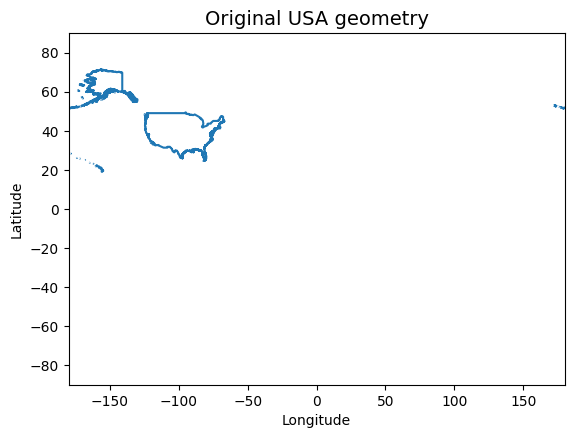

In [16]:
# USA original geometry
gdf_countries[gdf_countries["ID"] == "US"].boundary.plot()
plt.title(f"Original USA geometry", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180,180)
plt.ylim(-90,90)

In [17]:
# Alaska

# box definition
alaska_box = [
    box(-180, 47, -127, 73),  # main Alaska
    box(171, 50, 180, 54)     # wrap-around part
]

# attributes definition
alaska_row = {
    "NAME": "Alaska (US)",
    "ISO3_CODE": "USA",
    "ID": "AK"
}

2026-03-13 18:01:55 - root - INFO - Country United States processing...
2026-03-13 18:01:55 - root - INFO - Splitting Alaska (US) from United States ...
2026-03-13 18:01:55 - root - INFO - Country Alaska (US) split successfully and added to the final gdf


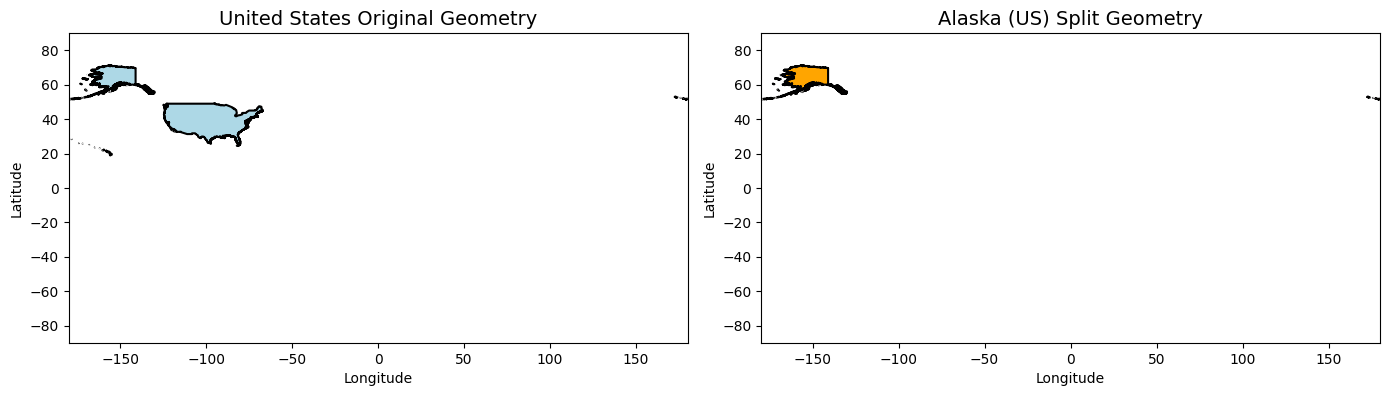

In [18]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "United States", alaska_box, alaska_row)

In [19]:
# Hawaii

# box definition
hawaii_box = box(-180, 18, -154, 27)

# attributes definition
hawaii_row = {
    "NAME": "Hawaii (US)",
    "ISO3_CODE": "USA",
    "ID": "HI"
}

2026-03-13 18:01:55 - root - INFO - Country United States processing...
2026-03-13 18:01:55 - root - INFO - Splitting Hawaii (US) from United States ...
2026-03-13 18:01:55 - root - INFO - Country Hawaii (US) split successfully and added to the final gdf


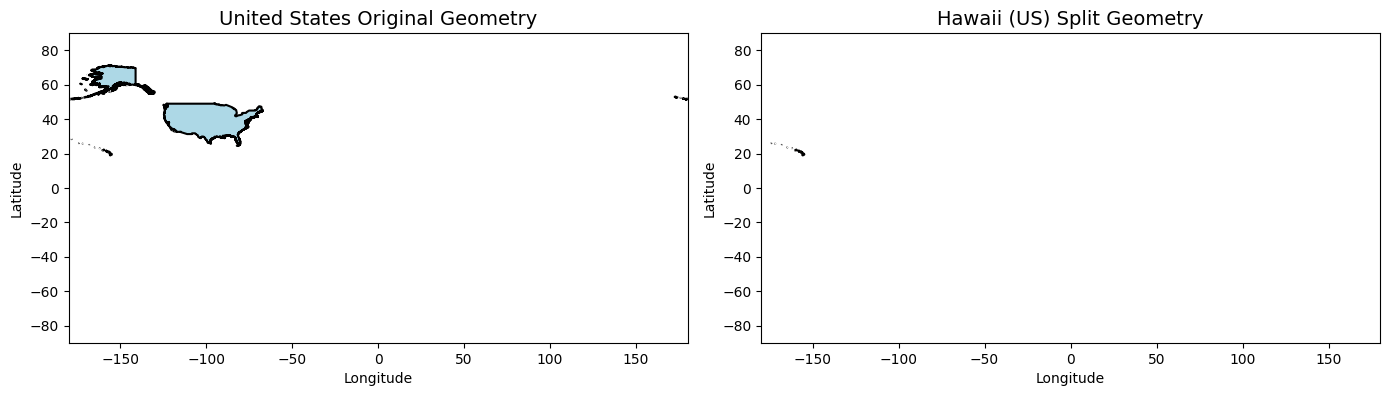

In [20]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "United States", hawaii_box, hawaii_row)

In [21]:
# Continental US

# box definition
conus_box = box(-125, 24, -66.5, 50)

# attributes definition
conus_row = {
    "NAME": "United States",
    "ISO3_CODE": "USA",
    "ID": "US"
}

2026-03-13 18:01:56 - root - INFO - Country United States processing...
2026-03-13 18:01:56 - root - INFO - Mainland processing...


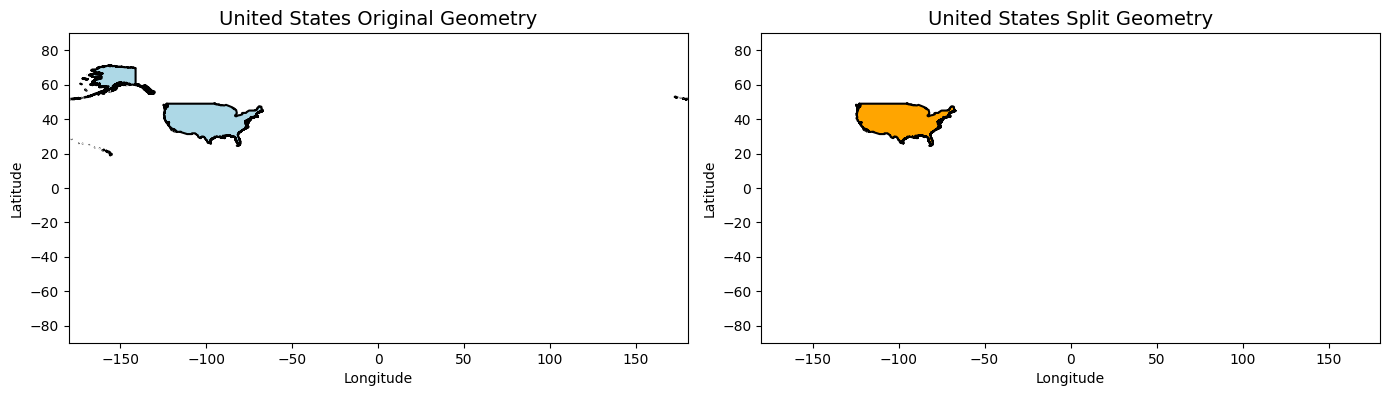

In [22]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "United States", conus_box, conus_row)

CHINA contains PARACEL ISLANDS

(-90.0, 90.0)

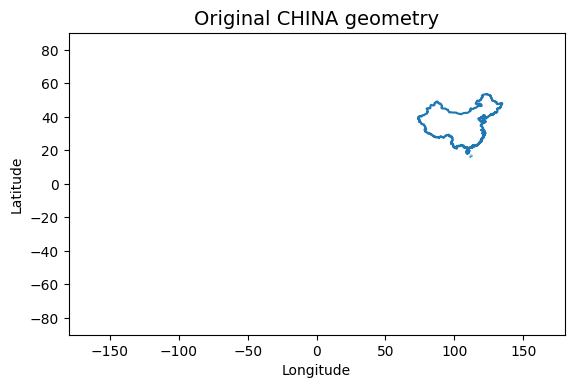

In [23]:
# CHINA original geometry
gdf_countries[gdf_countries["ID"] == "CN"].boundary.plot()
plt.title(f"Original CHINA geometry", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180,180)
plt.ylim(-90,90)

In [24]:
# Paracel Islands

# box definition
paracel_box = box(110, 15, 114, 17.5)

# attributes definition
paracel_row = {
    "NAME": "Paracel Islands (Disputed Territory)",
    "ID": "XA"
}

2026-03-13 18:01:56 - root - INFO - Country China processing...
2026-03-13 18:01:56 - root - INFO - Splitting Paracel Islands (Disputed Territory) from China ...
2026-03-13 18:01:56 - root - INFO - Country Paracel Islands (Disputed Territory) split successfully and added to the final gdf


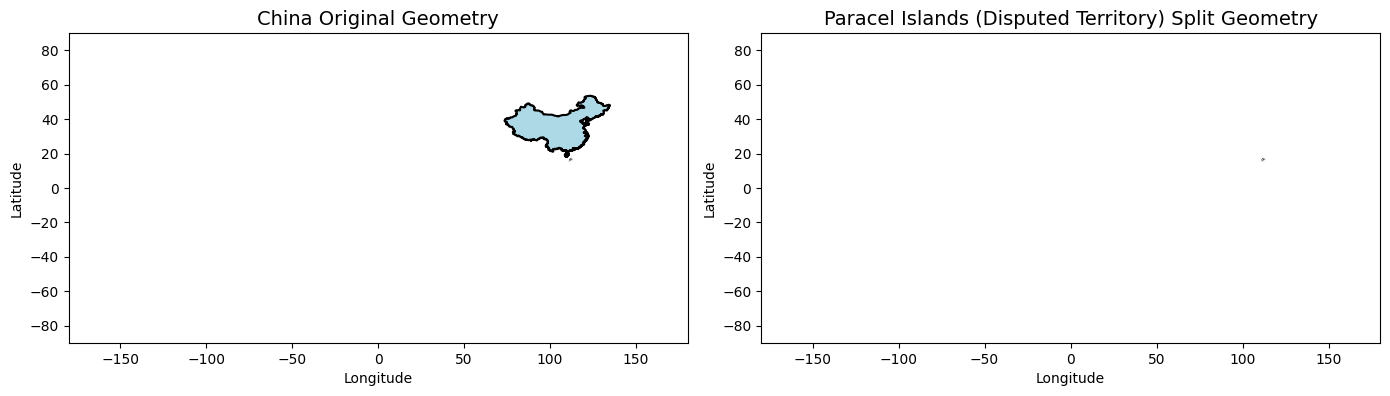

In [25]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "China", paracel_box, paracel_row)

In [26]:
# China mainland

# box definition
chn_box = box(70, 15, 140, 55) - paracel_box

# attributes definition
chn_row = {
    "NAME": "China",
    "ISO3_CODE": "CHN",
    "ID": "CN"
}

2026-03-13 18:01:56 - root - INFO - Country China processing...
2026-03-13 18:01:56 - root - INFO - Mainland processing...


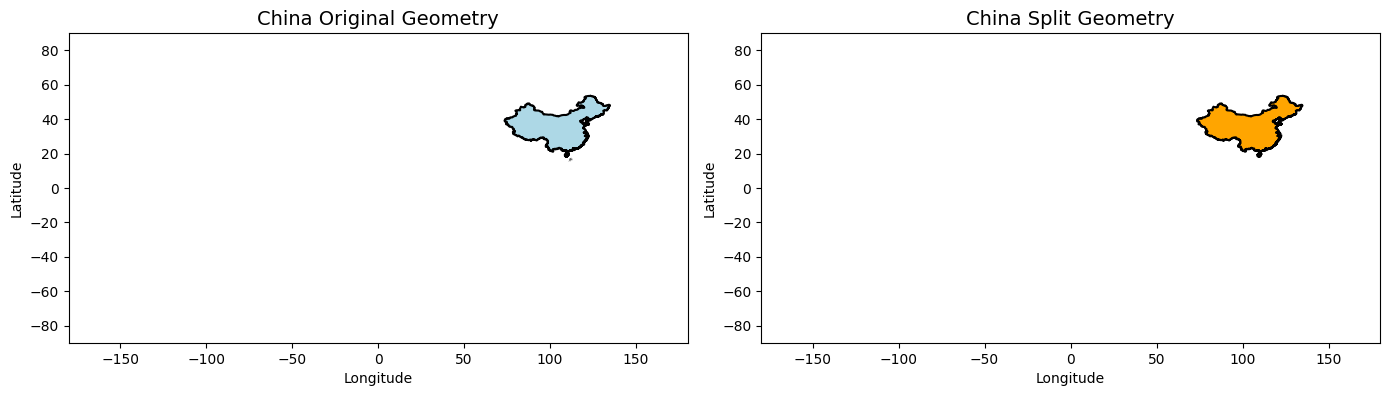

In [27]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "China", chn_box, chn_row)

FRANCE contains FRENCH GUIANA, GUADALUPE, MARTINIQUE, SAINT MARTIN, MAYOTTE, REUNION

(-90.0, 90.0)

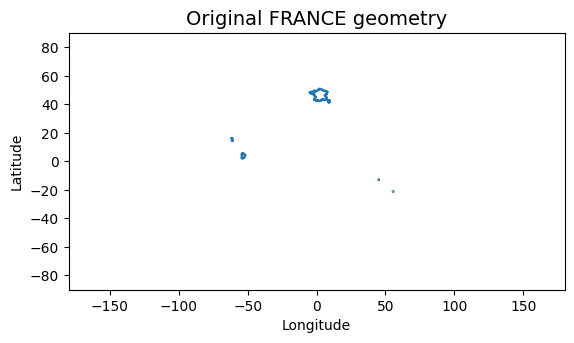

In [28]:
# FRANCE original geometry
gdf_countries[gdf_countries["ID"] == "FR"].boundary.plot()
plt.title(f"Original FRANCE geometry", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180,180)
plt.ylim(-90,90)

In [29]:
# French Guiana

# box definition
frguiana_box = box(-55, 1.5, -51, 6)

# attributes definition
frguiana_row = {
    "NAME": "French Guiana",
    "ISO3_CODE": "GUF",
    "ID": "GF"
}

2026-03-13 18:01:56 - root - INFO - Country France processing...
2026-03-13 18:01:56 - root - INFO - Splitting French Guiana from France ...
2026-03-13 18:01:56 - root - INFO - Country French Guiana split successfully and added to the final gdf


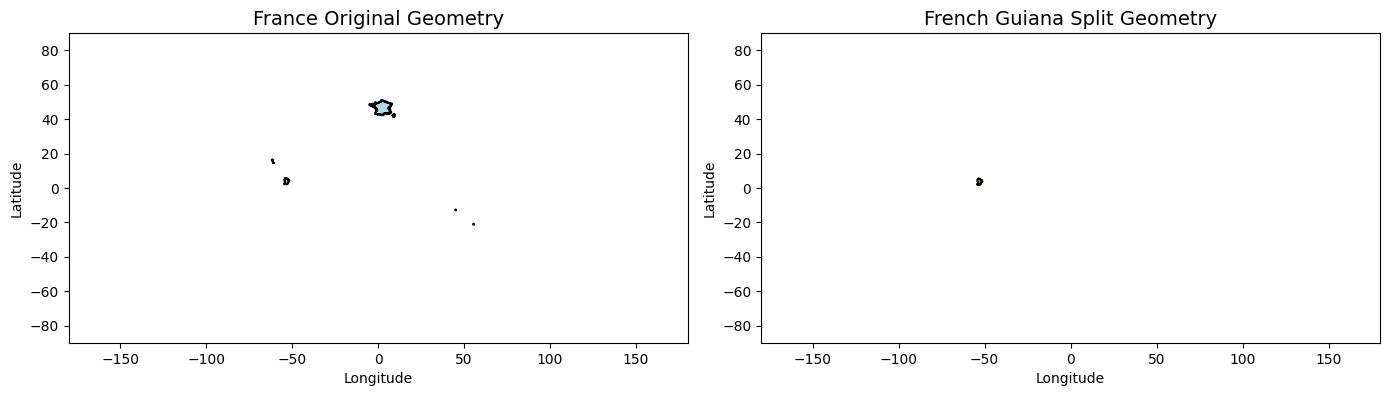

In [30]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "France", frguiana_box, frguiana_row)

In [31]:
# Guadeloupe

# box definition
guad_box = box(-60, 15.5, -62, 17)

# attributes definition
guad_row = {
    "NAME": "Guadeloupe",
    "ISO3_CODE": "GLP",
    "ID": "GP"
}

2026-03-13 18:01:57 - root - INFO - Country France processing...
2026-03-13 18:01:57 - root - INFO - Splitting Guadeloupe from France ...
2026-03-13 18:01:57 - root - INFO - Country Guadeloupe split successfully and added to the final gdf


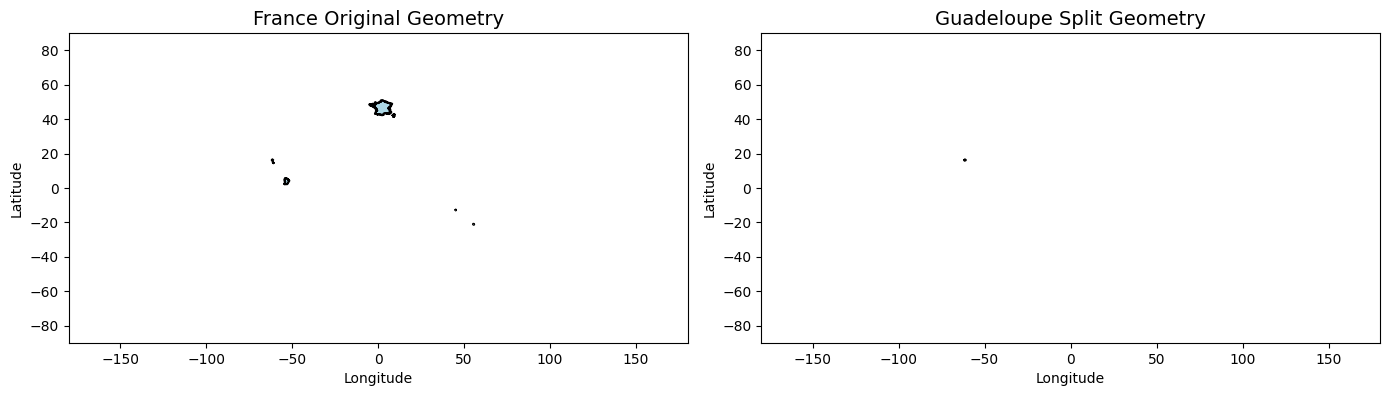

In [32]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "France", guad_box, guad_row)

In [33]:
# Martinique

# box definition
mart_box = box(-60, 14, -62, 15)

# attributes definition
mart_row = {
    "NAME": "Martinique",
    "ISO3_CODE": "MTQ",
    "ID": "MQ"
}

2026-03-13 18:01:57 - root - INFO - Country France processing...
2026-03-13 18:01:57 - root - INFO - Splitting Martinique from France ...
2026-03-13 18:01:57 - root - INFO - Country Martinique split successfully and added to the final gdf


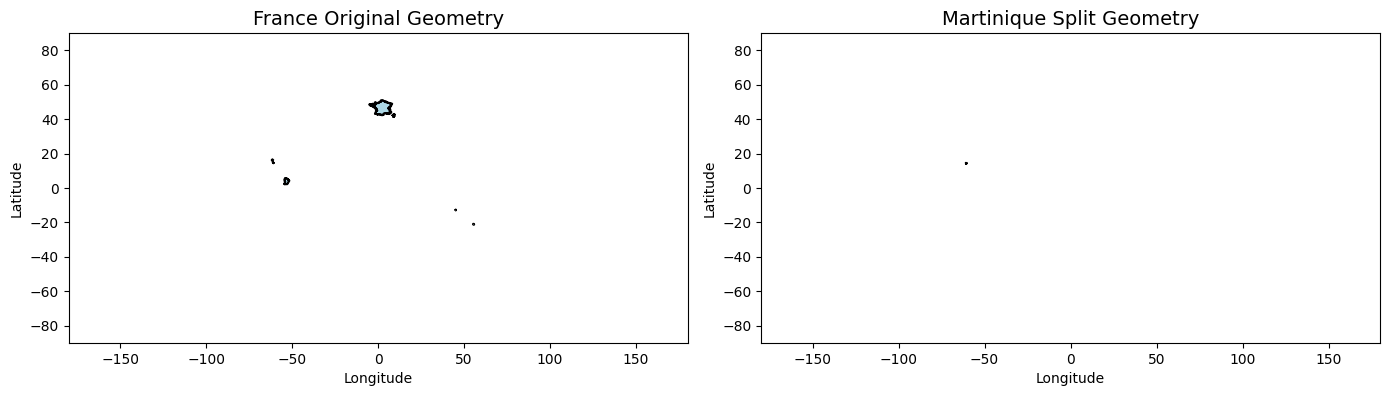

In [34]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "France", mart_box, mart_row)

In [35]:
# Saint Martin

# box definition
shn_box = box(-63.3, 18, -62.8, 18.2)

# attributes definition
shn_row = {
    "NAME": "Saint Martin",
    "ISO3_CODE": "MAF",
    "ID": "MF"
}

In [36]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "France", shn_box, shn_row)

2026-03-13 18:01:57 - root - INFO - Country France processing...
2026-03-13 18:01:57 - root - WARNING - No geometry found for Saint Martin


In [37]:
# Mayotte

# box definition
mayotte_box = box(44, -13.5, 45.5, -12.5)

# attributes definition
mayotte_row = {
    "NAME": "Mayotte",
    "ISO3_CODE": "MYT",
    "ID": "YT"
}

2026-03-13 18:01:57 - root - INFO - Country France processing...
2026-03-13 18:01:57 - root - INFO - Splitting Mayotte from France ...
2026-03-13 18:01:57 - root - INFO - Country Mayotte split successfully and added to the final gdf


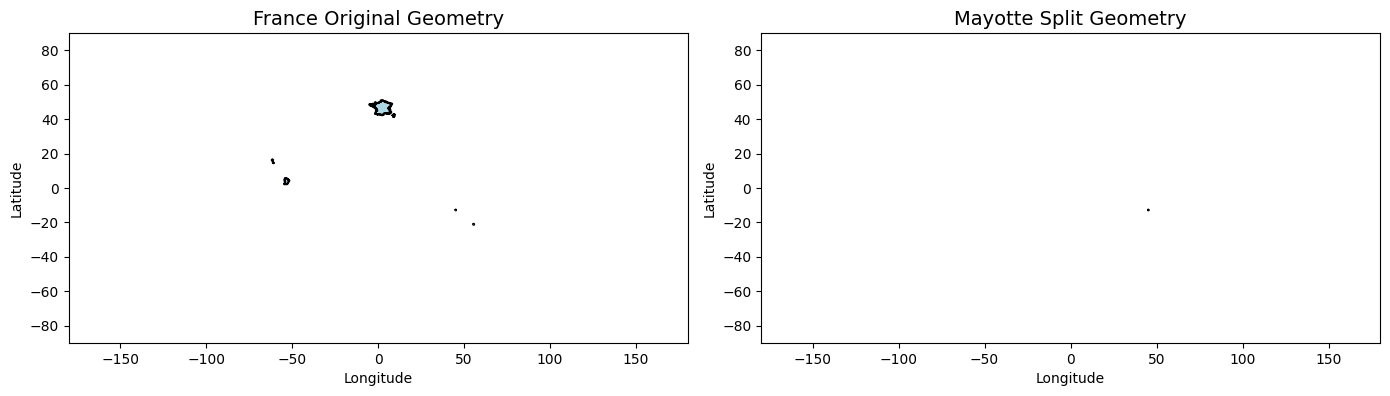

In [38]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "France", mayotte_box, mayotte_row)

In [39]:
# Réunion

# box definition
reunion_box = box(54, -22, 56, -20)

# attributes definition
reunion_row = {
    "NAME": "Réunion",
    "ISO3_CODE": "REU",
    "ID": "RE"
}

2026-03-13 18:01:57 - root - INFO - Country France processing...
2026-03-13 18:01:57 - root - INFO - Splitting Réunion from France ...
2026-03-13 18:01:57 - root - INFO - Country Réunion split successfully and added to the final gdf


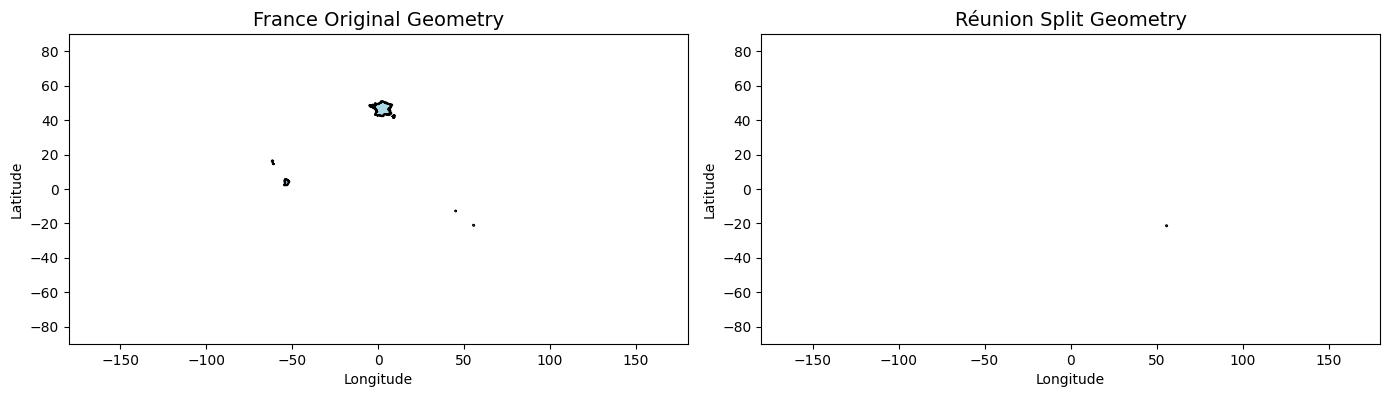

In [40]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "France", reunion_box, reunion_row)

In [41]:
# France (Europe)

# box definition
france_box = box(-70, -25, 70, 70) - frguiana_box - reunion_box - mayotte_box - guad_box - mart_box - shn_box

# attributes definition
france_row = {
    "NAME": "France",
    "ISO3_CODE": "FRA",
    "ID": "FR"
}

2026-03-13 18:01:58 - root - INFO - Country France processing...
2026-03-13 18:01:58 - root - INFO - Mainland processing...


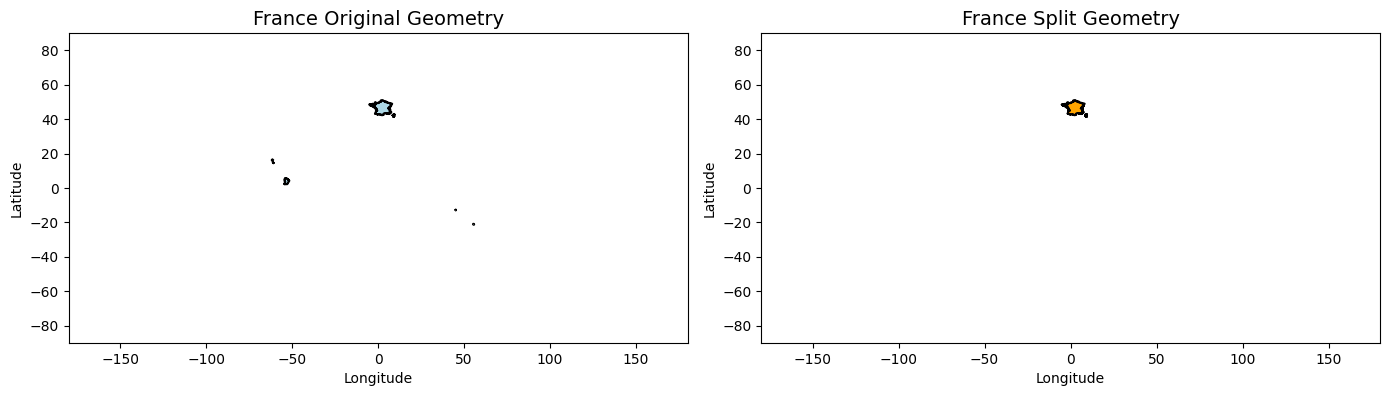

In [42]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "France", france_box, france_row)

gdf_countries_new.loc[gdf_countries_new['NAME'] == 'France', 'ISO3_CODE'] = 'FRA'

INDIAN OCEAN TERRITORIES contains CHRISTMAS ISLAND and COCOS KEELING ISLAND

(-90.0, 90.0)

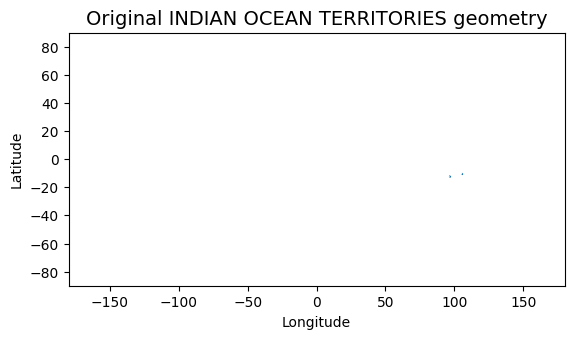

In [43]:
# INDIAN OCEAN TERRITORIES original geometry
gdf_countries[gdf_countries["NAME"] == "Indian Ocean Territories"].boundary.plot()
plt.title(f"Original INDIAN OCEAN TERRITORIES geometry", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180,180)
plt.ylim(-90,90)

In [44]:
# Christmas Island

# box definition
chris_box = box(105, -11, 106, -10)

# attributes definition
chris_row = {
    "NAME": "Christmas Island",
    "ISO3_CODE": "CXR",
    "ISO2_CODE": "CX",
    "ID": "CX"
}

2026-03-13 18:01:58 - root - INFO - Country Indian Ocean Territories processing...
2026-03-13 18:01:58 - root - INFO - Splitting Christmas Island from Indian Ocean Territories ...
2026-03-13 18:01:58 - root - INFO - Country Christmas Island split successfully and added to the final gdf


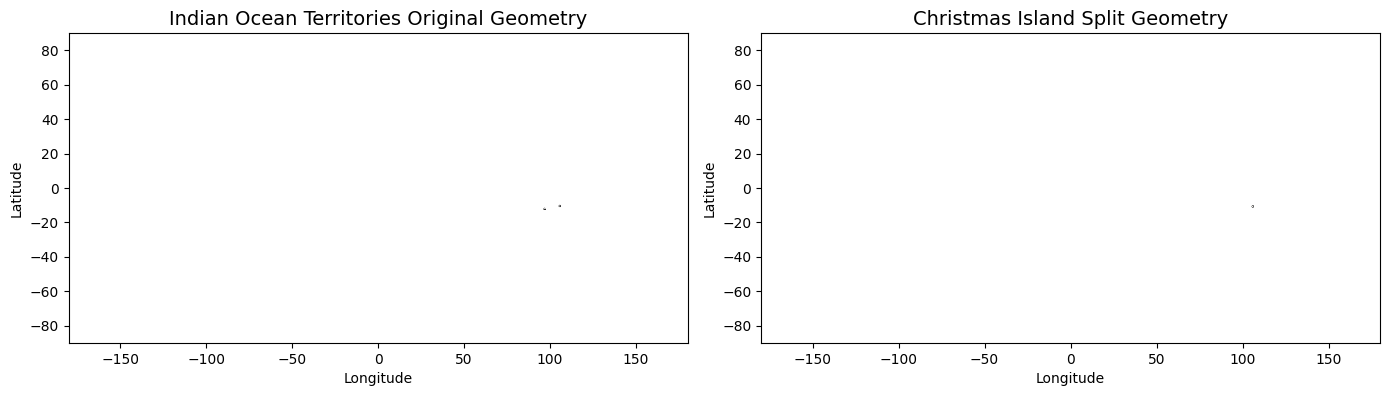

In [45]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "Indian Ocean Territories", chris_box, chris_row)

In [46]:
# Cocos Keeling Island

# box definition
cocos_box = box(96, -13, 98, -11)

# attributes definition
cocos_row = {
    "NAME": "Cocos (Keeling) Islands",
    "ISO3_CODE": "CCK",
    "ISO2_CODE": "CC",
    "ID": "CC"
}

2026-03-13 18:01:58 - root - INFO - Country Indian Ocean Territories processing...
2026-03-13 18:01:58 - root - INFO - Splitting Cocos (Keeling) Islands from Indian Ocean Territories ...
2026-03-13 18:01:58 - root - INFO - Country Cocos (Keeling) Islands split successfully and added to the final gdf


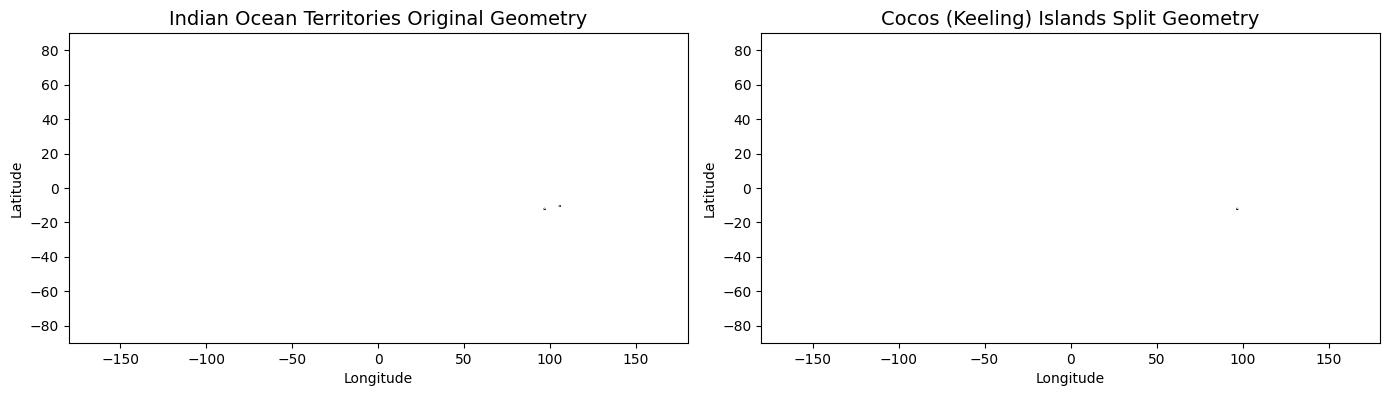

In [47]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "Indian Ocean Territories", cocos_box, cocos_row)

In [48]:
# the original geometry is now fully contained into the two split ones, so we can drop the original row
gdf_countries_new = gdf_countries_new.drop(gdf_countries_new[gdf_countries_new['NAME'] == 'Indian Ocean Territories'].index)

NORWAY contains SVALBARD AND JAN MAYEN and BOUVET ISLAND

(-90.0, 90.0)

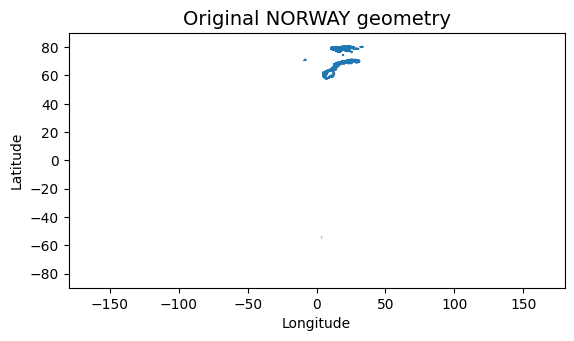

In [49]:
# NORWAY original geometry
gdf_countries[gdf_countries["NAME"] == "Norway"].boundary.plot()
plt.title(f"Original NORWAY geometry", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180,180)
plt.ylim(-90,90)

In [50]:
# Svalbard and Jan Mayen

# box definition
sjm_box = [
    box(9, 73, 34, 82),
    box(-10, 70, -7, 72)
]
# attributes definition
sjm_row = {
    "NAME": "Svalbard and Jan Mayen",
    "ISO3_CODE": "SJM",
    "ID": "SJ"
}


2026-03-13 18:01:58 - root - INFO - Country Norway processing...
2026-03-13 18:01:58 - root - INFO - Splitting Svalbard and Jan Mayen from Norway ...
2026-03-13 18:01:58 - root - INFO - Country Svalbard and Jan Mayen split successfully and added to the final gdf


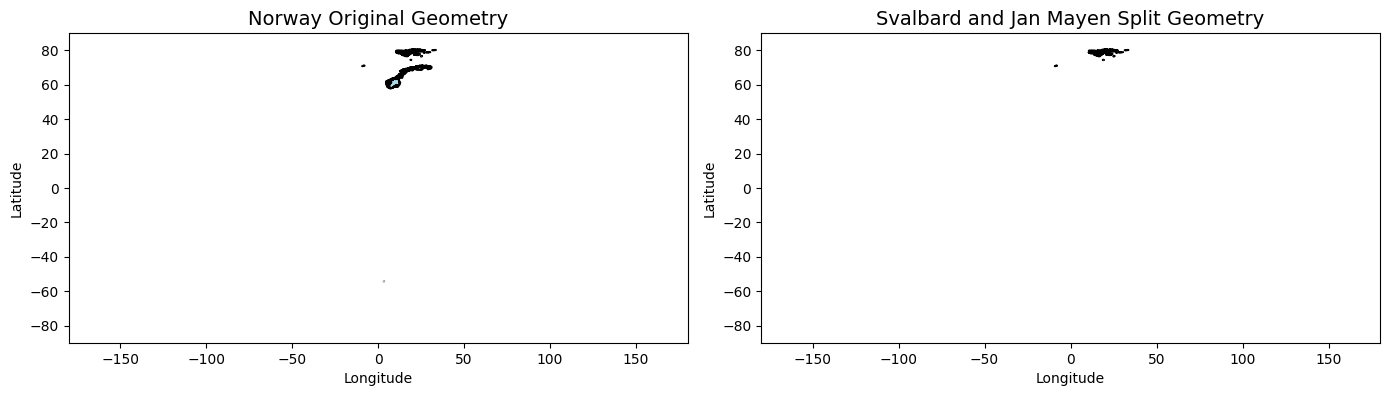

In [51]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "Norway", sjm_box, sjm_row)

In [52]:
# Bouvet Island

# box definition
bou_box = box(0, -56, 5, -53)

# attributes definition
bou_row = {
    "NAME": "Bouvet Island",
    "ISO3_CODE": "BVT",
    "ID": "BV"
}


2026-03-13 18:01:59 - root - INFO - Country Norway processing...
2026-03-13 18:01:59 - root - INFO - Splitting Bouvet Island from Norway ...
2026-03-13 18:01:59 - root - INFO - Country Bouvet Island split successfully and added to the final gdf


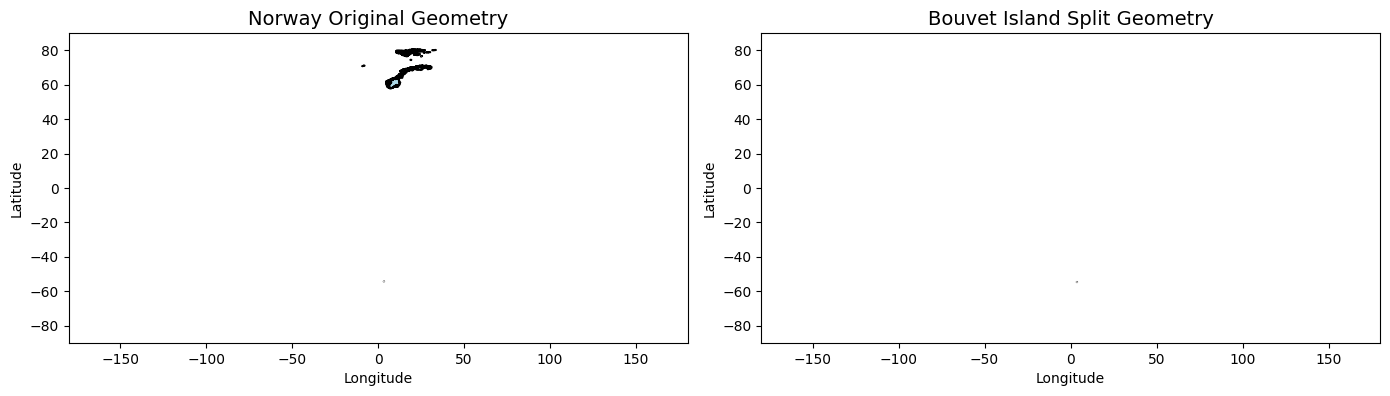

In [53]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "Norway", bou_box, bou_row)

In [54]:
# Norway mainland

# box definition
nor_box = box(3, 57, 32, 72)

# attributes definition
nor_row = {
    "NAME": "Norway",
    "ID": "NO"
}

2026-03-13 18:01:59 - root - INFO - Country Norway processing...
2026-03-13 18:01:59 - root - INFO - Mainland processing...


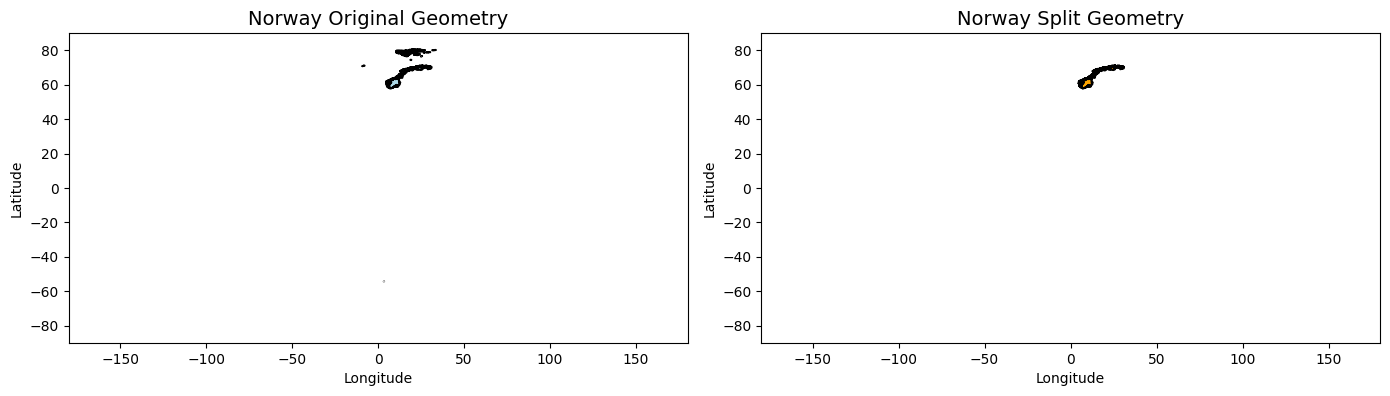

In [55]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "Norway", nor_box, nor_row)

gdf_countries_new.loc[gdf_countries_new['NAME'] == 'Norway', 'ISO3_CODE'] = 'NOR'

NEW ZEALAND contains TOKELAU

(-90.0, 90.0)

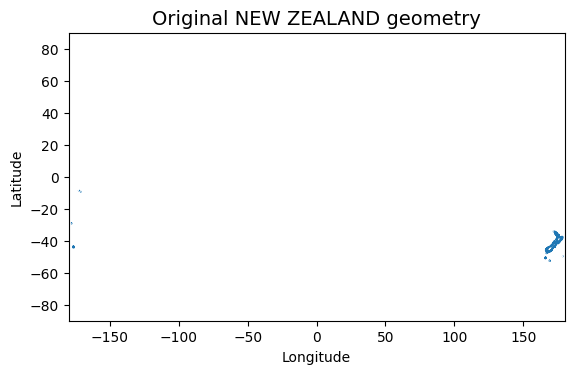

In [56]:
# NEW ZEALAND original geometry
gdf_countries[gdf_countries["NAME"] == "New Zealand"].boundary.plot()
plt.title(f"Original NEW ZEALAND geometry", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180,180)
plt.ylim(-90,90)

In [57]:
# Tokelau

# box definition
tkl_box = box(-174, -10, -170, -8)

# attributes definition
tkl_row = {
    "NAME": "Tokelau",
    "ISO3_CODE": "TKL",
    "ID": "TK"
}

2026-03-13 18:01:59 - root - INFO - Country New Zealand processing...
2026-03-13 18:01:59 - root - INFO - Splitting Tokelau from New Zealand ...
2026-03-13 18:01:59 - root - INFO - Country Tokelau split successfully and added to the final gdf


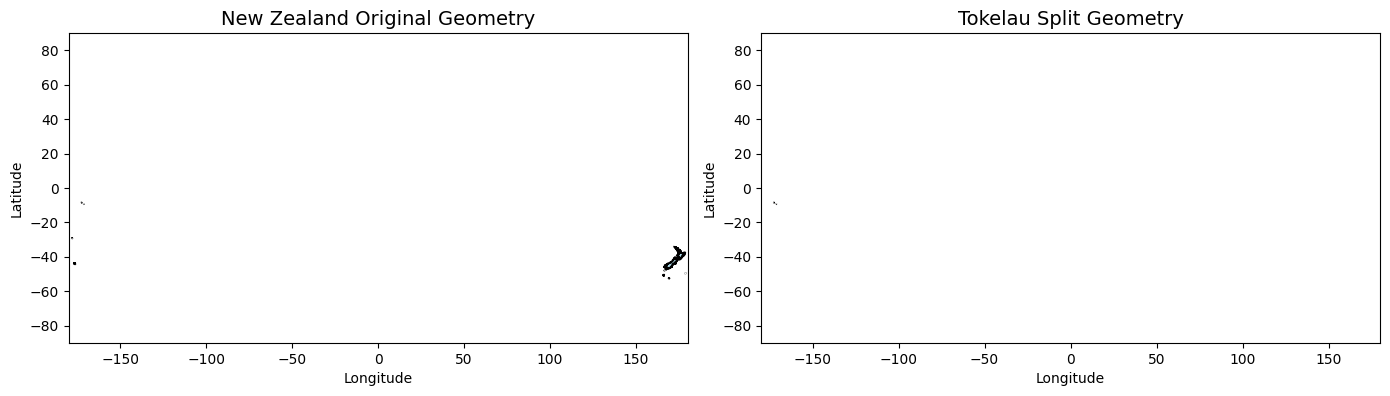

In [58]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "New Zealand", tkl_box, tkl_row)

In [59]:
# New Zealand

# box definition
nzl_box = box(-180, -90, 180, 90) - tkl_box

# attributes definition
nzl_row = {
    "NAME": "New Zealand",
    "ISO3_CODE": "NZL",
    "ID": "NZ"
}

2026-03-13 18:01:59 - root - INFO - Country New Zealand processing...
2026-03-13 18:01:59 - root - INFO - Mainland processing...


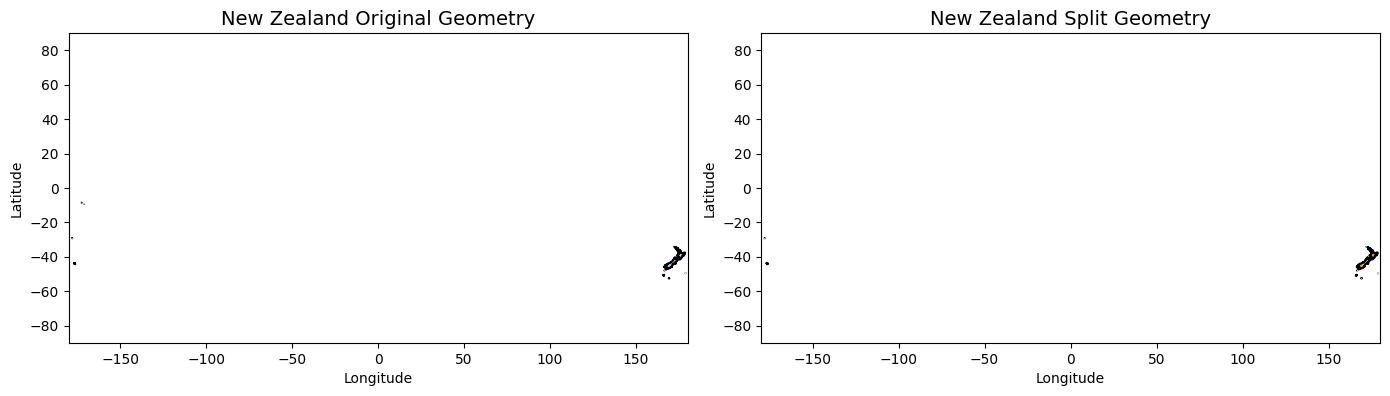

In [60]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "New Zealand", nzl_box, nzl_row)

Splitting processed finished

In [61]:
logging.info("Countries splitting processed finished")

2026-03-13 18:02:00 - root - INFO - Countries splitting processed finished


## MERGE REGIONS

In [62]:
# merging function

def merge_countries(gdf, filter_col, filter_values, base_row_value=None, override_attributes={}):
    """
    Merges countries of selected rows, drops them, and adds a new merged row.

    Parameters:
        gdf: GeoDataFrame
        filter_col: column name to filter on (str)
        filter_values: list of values to merge
        base_row_value: value in filter_col to copy attributes from (uses first row if None)
        override_attributes: dict of attributes to override on top of the base row
    """
    rows_to_merge = gdf[gdf[filter_col].isin(filter_values)]
    merged_geometry = unary_union(rows_to_merge.geometry)

    # Pick base row for attributes
    if base_row_value:
        base_row = rows_to_merge[rows_to_merge[filter_col] == base_row_value].iloc[0]
    else:
        base_row = rows_to_merge.iloc[0]  # default to first row

    # Build new row: start from base, override what you want
    new_row = base_row.to_dict()
    new_row['geometry'] = merged_geometry
    new_row.update(override_attributes)

    gdf = gdf.drop(rows_to_merge.index)
    new_gdf = gpd.GeoDataFrame([new_row], crs=gdf.crs)
    gdf = gpd.GeoDataFrame(pd.concat([gdf, new_gdf], ignore_index=True), crs=gdf.crs)

    return gdf

CORAL SEA ISLANDS, ASHMORE AND CARTIER ISLANDS are merged with AUSTRALIA

In [63]:
gdf_countries_new = merge_countries(gdf_countries_new, 'NAME', ['Australia', 'Coral Sea Islands', 'Ashmore and Cartier Islands'],
                 base_row_value='Australia',
                 override_attributes={'NAME': 'Australia'})

(-90.0, 0.0)

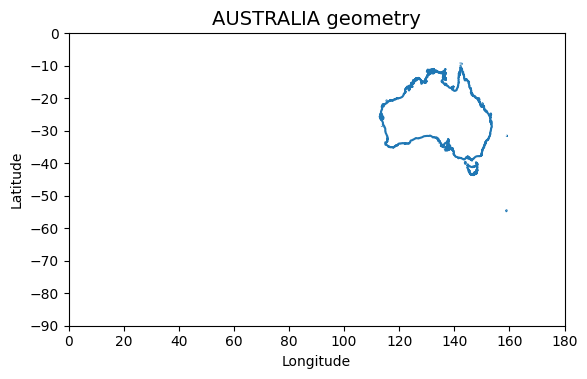

In [64]:
# AUSTRALIA
gdf_countries[gdf_countries["NAME"] == "Australia"].boundary.plot()
plt.title(f"AUSTRALIA geometry", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(0,180)
plt.ylim(-90,0)

In [65]:
gdf_countries_new = merge_countries(gdf_countries_new, 'NAME', ['Akrotiri', 'Dhekelia'],
                 override_attributes={'NAME': 'Cyprus U.K. Bases', 'ID': 'EWSB'})

In [66]:
# Check if the geometry exists and is valid
result = gdf_countries_new[gdf_countries_new['NAME'] == 'Cyprus U.K. Bases']
print(result.geometry.values)
print(result.geometry.is_empty.values)
print(result.geometry.is_valid.values)

<GeometryArray>
[<MULTIPOLYGON (((33.01 34.625, 33.009 34.597, 33.03 34.575, 33.03 34.569, 32...>]
Length: 1, dtype: geometry
[False]
[ True]


In [67]:
# Check if both names exist in your gdf before merging
print(gdf_countries_new[gdf_countries_new['NAME'].isin(['Akrotiri', 'Dhekelia'])]['NAME'].tolist())

[]


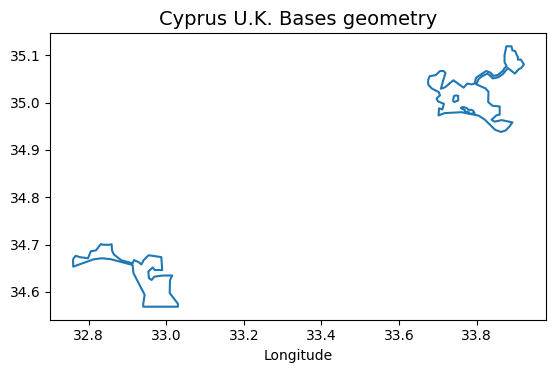

In [68]:
# Cyprus U.K. Bases
fig, ax = plt.subplots()
gdf_countries_new[gdf_countries_new["NAME"] == "Cyprus U.K. Bases"].boundary.plot(ax=ax)
plt.title("Cyprus U.K. Bases geometry", fontsize=14)
plt.xlabel("Longitude")
plt.show()

## METADATA

In [69]:
# All the countries are sourced from Natural Earth
gdf_countries_new["SOURCE"] = "Natural Earth Admin0 10m"


In [70]:
# Functions to assign other ISO codes from: Countries (ISO 3166-1)
def iso3_to_iso2(code):
    if not isinstance(code, str) or not code:  # handle None/NaN
        return None
    country = pycountry.countries.get(alpha_3=code)
    return country.alpha_2 if country else None

def iso3_to_num(code):
    if not isinstance(code, str) or not code:  # handle None/NaN
        return None
    country = pycountry.countries.get(alpha_3=code)
    return country.numeric if country else None

# Assign codes
gdf_countries_new["ISO2_CODE"] = gdf_countries_new["ISO3_CODE"].apply(iso3_to_iso2)
gdf_countries_new["ISON_CODE"] = gdf_countries_new["ISO3_CODE"].apply(iso3_to_num)


In [71]:
# Add the NUM_ID from the csv file
lookup = codes_id.set_index("ID")["NUM_ID"]
gdf_countries_new["NUM_ID"] = gdf_countries_new["ID"].map(lookup)
gdf_countries_new["NUM_ID"] = gdf_countries_new["NUM_ID"].astype(str).str.strip()
gdf_countries_new["NUM_ID"] = pd.to_numeric(gdf_countries_new["NUM_ID"], errors='coerce').astype('Int64')

In [72]:
gdf_countries_new

,ID,NAME,ISO3_CODE,ISO2_CODE,ISON_CODE,NUM_ID,NE_ID,SOURCE,geometry
0,ID,Indonesia,IDN,ID,360,97,1.159321e+09,Natural Earth Admin0 10m,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,MY,Malaysia,MYS,MY,458,135,1.159321e+09,Natural Earth Admin0 10m,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,CL,Chile,CHL,CL,152,45,1.159320e+09,Natural Earth Admin0 10m,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,BO,Bolivia,BOL,BO,068,30,1.159320e+09,Natural Earth Admin0 10m,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,PE,Peru,PER,PE,604,165,1.159321e+09,Natural Earth Admin0 10m,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."
...,...,...,...,...,...,...,...,...,...
262,SJ,Svalbard and Jan Mayen,SJM,SJ,744,194,NaN,Natural Earth Admin0 10m,"MULTIPOLYGON (((-7.98681 71.11347, -8.0089 71...."
263,BV,Bouvet Island,BVT,BV,074,38,NaN,Natural Earth Admin0 10m,"POLYGON ((3.45729 -54.39007, 3.47779 -54.39674..."
264,TK,Tokelau,TKL,TK,772,200,NaN,Natural Earth Admin0 10m,"MULTIPOLYGON (((-171.19551 -9.35068, -171.1997..."
265,AU,Australia,AUS,AU,036,15,1.159320e+09,Natural Earth Admin0 10m,"MULTIPOLYGON (((115.65699 -32.20941, 115.64942..."


## OUTPUT FILE

In [73]:
# Save GeoDataFrame
gdf_countries_new.to_file(countries_from_ne_path)

logging.info(f"Saved Shapefile to: {countries_from_ne_path}")

2026-03-13 18:02:00 - pyogrio._io - INFO - Created 267 records
2026-03-13 18:02:00 - root - INFO - Saved Shapefile to: data/countries_from_ne_10m/countries_from_ne_10m.shp
